# Soft Actor Critic

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
import random 

%matplotlib inline

from IPython.display import HTML

from pendulum_plant.pendulum_plant import PendulumPlant
from pendulum_plant.simulation import Simulator

from sac.sac import sac_trainer
from sac.sac_controller import SacController

Set parameters for pendulum and enviroment

In [2]:
# pendulum parameters
mass = 0.06
length = 0.1
inertia = mass*length**2
damping = 0.0004
gravity = 9.81
coulomb_fric = 0.0
torque_limit = 0.02

# environment parameters
dt = 0.05
integrator = "runge_kutta"
max_steps = 200
reward_type = "combined_reward"
target = [np.pi, 0]
target_epsilon = [0.05, 0.05]
random_init = "everywhere"


# Training

In [3]:
log_dir = "log_data/sac_training"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

# training parameters
learning_rate = 0.0003 
training_timesteps = 1e5 # changed from 1e6
reward_threshold = 40_000
eval_frequency = 6000
n_eval_episodes = 20

# create trainer
trainer = sac_trainer(log_dir=log_dir)

# intitalize pendulum, enviroment and agent with parameters from before
trainer.init_pendulum(mass=mass,
                      length=length,
                      inertia=inertia,
                      damping=damping,
                      coulomb_friction=coulomb_fric,
                      gravity=gravity,
                      torque_limit=torque_limit)

trainer.init_environment(dt=dt,
                         integrator=integrator,
                         max_steps=max_steps,
                         reward_type=reward_type,
                         target=target,
                         state_target_epsilon=target_epsilon,
                         random_init=random_init,
                         state_representation=3)

trainer.init_agent(learning_rate=learning_rate,
                   warm_start=False,
                   warm_start_path="",
                   verbose=1)

# train the model
trainer.train(training_timesteps=training_timesteps,
              reward_threshold=reward_threshold,
              eval_frequency=eval_frequency,
              n_eval_episodes=n_eval_episodes,
              verbose=1, 
              )

/opt/homebrew/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/opt/homebrew/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to log_data/sac_training/tb_logs/SAC_1
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 202       |
|    ep_rew_mean     | -1.97e+03 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 7344      |
|    time_elapsed    | 0         |
|    total_timesteps | 808       |
----------------------------------


/opt/homebrew/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 202       |
|    ep_rew_mean     | -1.99e+03 |
| time/              |           |
|    episodes        | 8         |
|    fps             | 7446      |
|    time_elapsed    | 0         |
|    total_timesteps | 1616      |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 202       |
|    ep_rew_mean     | -1.96e+03 |
| time/              |           |
|    episodes        | 12        |
|    fps             | 213       |
|    time_elapsed    | 11        |
|    total_timesteps | 2424      |
| train/             |           |
|    actor_loss      | 139       |
|    critic_loss     | 69.9      |
|    ent_coef        | 0.383     |
|    ent_coef_loss   | -1        |
|    learning_rate   | 0.0003    |
|    n_updates       | 3384      |
----------------------------------
----------------------------------
| rollout/          

/opt/homebrew/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=6000, episode_reward=-2020.00 +/- 0.00
Episode length: 202.00 +/- 0.00
----------------------------------
| eval/              |           |
|    mean_ep_length  | 202       |
|    mean_reward     | -2.02e+03 |
| time/              |           |
|    total_timesteps | 6000      |
| train/             |           |
|    actor_loss      | 398       |
|    critic_loss     | 885       |
|    ent_coef        | 0.32      |
|    ent_coef_loss   | -0.0972   |
|    learning_rate   | 0.0003    |
|    n_updates       | 31992     |
----------------------------------
New best mean reward!
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 202       |
|    ep_rew_mean     | -1.62e+03 |
| time/              |           |
|    episodes        | 32        |
|    fps             | 55        |
|    time_elapsed    | 117       |
|    total_timesteps | 6464      |
| train/             |           |
|    actor_loss      | 406       |
|    critic_l

KeyboardInterrupt: 

# Simulate swing using SAC controller

Final torque: -0.015265998430550098


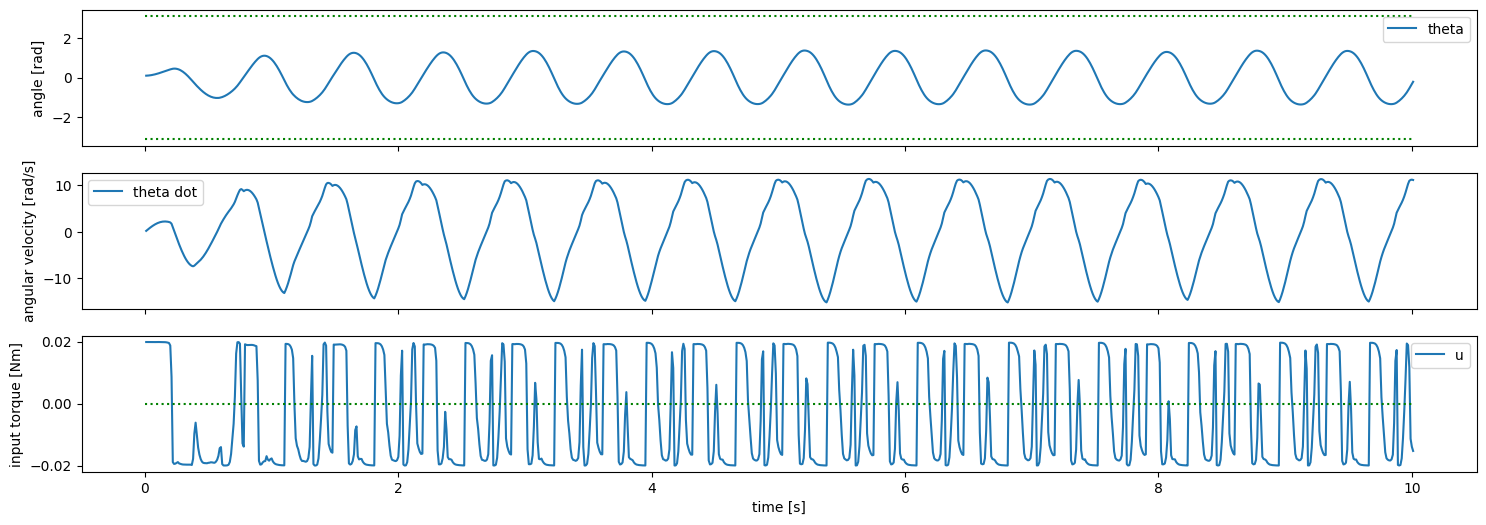

In [6]:
# initialize the pendulum
pendulum = PendulumPlant(mass=mass,
                         length=length,
                         damping=damping,
                         gravity=gravity,
                         coulomb_fric=coulomb_fric,
                         inertia=inertia,
                         torque_limit=torque_limit)

sim = Simulator(plant=pendulum)

# get the controller we trained earlier
#model_path = "data_models/sac_model.zip"
#model_path = "log_data/sac_training/best_model/best_model.zip"
model_path = "log_data/sac_training_rail_04tl_08dp/best_model/best_model.zip"

controller = SacController(model_path=model_path,
                           torque_limit=torque_limit,
                           use_symmetry=True,
                           state_representation=3,
                           deterministic=True)

# simulate
x0_sim = [0.1, 0.0]
dt = 0.01
t_final = 10
integrator = "runge_kutta"

T, X, U = sim.simulate(t0=0.0,
                                   x0=x0_sim,
                                   tf=t_final,
                                   dt=dt,
                                   controller=controller,
                                   integrator=integrator)


fig, ax = plt.subplots(3, 1, figsize=(18, 6), sharex="all")
print(f"Final torque: {U[-1]}")
ax[0].plot(T, np.asarray(X).T[0], label="theta")
ax[0].hlines(y=[-np.pi, np.pi], xmin=0, xmax = t_final, linestyles = ':', colors='g')
ax[0].set_ylabel("angle [rad]")
ax[0].legend(loc="best")
ax[1].plot(T, np.asarray(X).T[1], label="theta dot")
ax[1].set_ylabel("angular velocity [rad/s]")
ax[1].legend(loc="best")
ax[2].plot(T, np.asarray(U).flatten(), label="u")
ax[2].set_xlabel("time [s]")
ax[2].set_ylabel("input torque [Nm]")
ax[2].hlines(y=0, xmin=0, xmax=t_final, linestyles = ':', colors='g')
ax[2].legend(loc="best")
plt.show()



# Running on Hardware